In [ ]:
# CELL 1: Import necessary libraries and load data 
#--------------------------------------------------------------

import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from scipy.special import expit
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.modules.loss import _Loss
from torch import Tensor
from sklearn.utils import resample


# Load and preprocess the Adult dataset
data = pd.read_csv('.../adult_reconstruction.csv') # change path to where the dataset is stored if needed
data = pd.DataFrame(data)

data['native-country'] = data['native-country'].replace(' ?',np.nan)
data['workclass'] = data['workclass'].replace(' ?',np.nan)
data['occupation'] = data['occupation'].replace(' ?',np.nan)

data = data.drop(['education-num'], axis=1)
data.dropna(how='any',inplace=True)

# Binarize the income variable (1 if >50K, else 0)
def bi(input):
  return np.where(input > 50000, 1, 0)

# Clip the dataset to a fraction of its original size (if needed)
def clip(df, a):
  perm = np.random.permutation(df.index)
  m = len(df.index)
  clip_end = int(a*m)
  cliped = df.iloc[:clip_end]
  return cliped

for col in set(data.columns) - set(data.describe().columns):
  data[col] = data[col].astype('category')

# One-hot encode categorical variables
def oneHotCatVars(df, df_cols):

    df_1 = df.drop(columns = df_cols, axis = 1)
    df_2 = pd.get_dummies(df[df_cols])

    return (pd.concat([df_1, df_2], axis=1, join='inner'))

data_preprocessed = oneHotCatVars(data, data.select_dtypes('category').columns)
normalize_columns = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# Normalize the specified columns using StandardScaler
def normalize(columns):
  scaler = preprocessing.StandardScaler()
  data_preprocessed[columns] = scaler.fit_transform(data_preprocessed[columns])


normalize(normalize_columns)

data_w = data_preprocessed[data_preprocessed['race_White'] == 1]
data_b = data_preprocessed[data_preprocessed['race_Black'] == 1]

data_preprocessed = pd.concat([data_w, data_b])

x_train, x_test = train_test_split(data_preprocessed)

# Prepare the training and testing datasets by separating the features, labels, and sensitive attributes
train_x = x_train.drop(['income'],axis=1)
train_x = train_x.drop(['race_White'],axis=1)
train_x = train_x.drop(['race_Black'],axis=1)
train_label = bi(x_train['income'].to_numpy())
train_sen = x_train['race_Black'].to_numpy()
test_x = x_test.drop(['income'],axis=1)
test_x = test_x.drop(['race_White'],axis=1)
test_x = test_x.drop(['race_Black'],axis=1)
test_label = bi(x_test['income'].to_numpy())
test_sen = x_test['race_Black'].to_numpy()

# Create PyTorch Dataset for training
class ShelterOutcomeDataset(Dataset):
    def __init__(self, X, Y, A):
        self.x = X.to_numpy().astype(np.float32)
        self.y = Y
        self.a =  A

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.a[idx]

In [ ]:
# Cell 2: Define the PGD attack and the neural network model
#--------------------------------------------------------------

"""
	Function to perform the PGD attack on the model. It takes in the model, input images, labels, epsilon (maximum perturbation), alpha (step size), and number of iterations. 
	It returns the adversarially perturbed data. The attack iteratively perturbs the input in the direction of the gradient of the loss with respect to the input, 
 	while ensuring that the perturbation does not exceed the specified epsilon and that the perturbed data remain within valid ranges.
"""
def pgd_attack(model, images, labels, eps, alpha=2/255, iters=40):
    loss = nn.CrossEntropyLoss()

    ori_images = images.data

    for i in range(iters) :
        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        cost = loss(outputs, labels)
        cost.backward()

        adv_images = images + alpha*images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach_()

    return images

"""
	Defines the neural network model for classification. The Classifier_complx class is a simple feedforward neural network with two hidden layers and an output layer. 
	The forward method defines the forward pass of the network, applying ReLU activation functions after the hidden layers and a log softmax activation at the output 
 	layer.
"""
class Classifier_complx(nn.Module):
    def __init__(self, input_size = 104, hidden_size = 512):
        super(Classifier_complx, self).__init__()

        self.dense1 = nn.Linear(input_size, hidden_size)
        self.dense2 = nn.Linear(hidden_size, hidden_size)
        self.dense4 = nn.Linear(hidden_size, 2)

    def forward(self, x):
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        x = self.dense4(x)

        return F.log_softmax(x,-1)

train_ds = ShelterOutcomeDataset(train_x, train_label, train_sen)
test_ds = ShelterOutcomeDataset(test_x, test_label, test_sen)
con = 0.4
eps = 0.1

batch_size_train, batch_size_test = 128, test_x.shape[0]
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size_train, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size_test, shuffle=False)

classifier = Classifier_complx()
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.8)

"""
	Function to train the model for one epoch. It iterates through the training data, computes the loss (including the EOD loss for both clean and adversarial examples), 
 	and updates the model parameters using backpropagation. The function first computes the standard classification loss on the clean examples, then generates adversarial 
  	examples using the PGD attack, computes the EOD loss for the adversarial examples, and combines it with the classification loss to update the model parameters. 
	The EOD loss is calculated based on the differences in true positive rates and true negative rates between the privileged and unprivileged groups for both clean and adversarial examples.
"""
def train(epoch):

  classifier.train()

  for batch_idx, (x, y, a) in enumerate(train_loader):
    x.requires_grad = True
    optimizer.zero_grad()
    
    # Calculate the EOD loss for the clean examples
    idx_bp = np.where(np.logical_and(a==1,y==1))
    idx_wp = np.where(np.logical_and(a==0,y==1))
    idx_bn = np.where(np.logical_and(a==1,y==0))
    idx_wn = np.where(np.logical_and(a==0,y==0))
    output = classifier(x)
    p1 = torch.squeeze(output[[idx_bp]],0) / len(np.array(idx_bp))
    p2 = torch.squeeze(output[[idx_wp]],0) / len(np.array(idx_wp))
    p3 = torch.squeeze(output[[idx_bn]],0) / len(np.array(idx_bn))
    p4 = torch.squeeze(output[[idx_wn]],0) / len(np.array(idx_wn))
    bp = output[idx_bp]
    wp = output[idx_wp]
    bn = output[idx_bn]
    wn = output[idx_wn]
    eod = abs(torch.sum(torch.exp(bn)[:,0]) / len(np.array(idx_bn)[0]) - torch.sum(torch.exp(wn)[:,0]) / len(np.array(idx_wn)[0])) + abs(torch.sum(torch.exp(bp)[:,1]) / len(np.array(idx_bp)[0]) - torch.sum(torch.exp(wp)[:,1]) / len(np.array(idx_wp)[0]))
   
	# calculate the classification loss for the clean examples
    loss = F.nll_loss(output, y)
    
    # generate adversarial examples using the PGD attack
    x_adv = pgd_attack(classifier, x, y, eps)
    output_adv  = classifier(x_adv)
	
    bp_adv = output_adv[idx_bp] / len(np.array(idx_bp))
    wp_adv = output_adv[idx_wp] / len(np.array(idx_wp))
    bn_adv = output_adv[idx_bn] / len(np.array(idx_bn))
    wn_adv = output_adv[idx_wn] / len(np.array(idx_wn))
    
    # calculate the EOD loss for the adversarial examples and combine it with the classification loss
    eod_adv = abs(torch.sum(torch.exp(bn_adv)[:,0]) / len(np.array(idx_bn)[0]) - torch.sum(torch.exp(wn_adv)[:,0]) / len(np.array(idx_wn)[0])) + abs(torch.sum(torch.exp(bp_adv)[:,1]) / len(np.array(idx_bp)[0]) - torch.sum(torch.exp(wp_adv)[:,1]) / len(np.array(idx_wp)[0]))
    
    # combine the classification loss and the EOD loss for the adversarial examples
    loss_adv = F.nll_loss(classifier(x_adv), y) + con * eod_adv

    loss_adv.backward()
    #loss.backward()
    optimizer.step()

    if batch_idx % 10 == 0:
      train_losses.append(loss_adv.item())
      train_counter.append(
        (batch_idx*128) + ((epoch-1)*len(train_loader.dataset)))
    if batch_idx % 20 == 0:
      print(f'Epoch {epoch}: [{batch_idx*len(x)}/{len(train_loader.dataset)}] Loss: {loss_adv.item()}')


"""
	Function to evaluate the model on the test dataset. It computes the average loss and accuracy of the model on the test data. The function iterates through the test data, 
 	computes the loss for each batch, and counts the number of correct predictions to calculate the overall accuracy. The results are printed at the end of each epoch.
"""
def test(epoch):

  classifier.eval()
  test_loss = 0
  correct = 0

  with torch.no_grad():
    for x, y, a in test_loader:
      y = y.long()
      output = classifier(x)
      test_loss += F.nll_loss(output, y).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(y.data.view_as(pred)).sum()
  test_losses.append(test_loss)
  test_counter.append(len(train_loader.dataset)*epoch)

  print(f'Test result of FC on epoch {epoch}: Avg loss is {test_loss}, Accuracy: {100.*correct/len(test_loader.dataset)}%')

train_losses = []
train_counter = []
test_losses = []
test_counter = []
max_epoch = 100

for epoch in range(1, max_epoch+1):
  train(epoch)
  test(epoch)

"""
	Evaluate the model on the test dataset and compute fairness metrics. The function model_eval computes various performance metrics such as true positive rate, 
 	true negative rate, false positive rate, false negative rate, and accuracy for both the privileged and unprivileged groups.
"""
def model_eval(actual, pred):

    confusion = pd.crosstab(actual, pred, rownames=['Actual'], colnames=['Predicted'])
    TP = confusion.loc[1,1] + 1
    TN = confusion.loc[0,0] + 1
    FP = confusion.loc[0,1] + 1
    FN = confusion.loc[1,0] + 1

    out = {}
    out['ALL'] = (TP+TN+FP+FN-4)
    out['DP'] = (TP+FP-2)/(TP+TN+FP+FN-4)
    out['TPR'] =  (TP-1)/(TP+FN-2)
    out['TNR'] = (TN-1)/(FP+TN-2)
    out['FPR'] = (FP-1)/(FP+TN-2)
    out['FNR'] = (FN-1)/(TP+FN-2)
    out['ACR'] = (TP+TN-2)/(TP+TN+FP+FN-4)

    return out

for x, y, a in test_loader:
      y = y.long()
      output = classifier(x)
      idx_b = np.where(a==1)
      y_b = y[[idx_b]]
      pred_b = output[[idx_b]]
      pred_b = torch.squeeze(pred_b,0).data.max(1, keepdim=True)[1]
      idx_w = np.where(a==0)
      y_w = y[[idx_w]]
      pred_w = output[[idx_w]]
      pred_w = torch.squeeze(pred_w,0).data.max(1, keepdim=True)[1]

w = model_eval(torch.squeeze(y_w,0), pred_w.detach().numpy().reshape(pred_w.shape[0]))
b = model_eval(torch.squeeze(y_b,0), pred_b.detach().numpy().reshape(pred_b.shape[0]))

DI1 = 100 * abs(w['DP'] - b['DP'])
DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
w_TNR  = 100 * w['TNR']
w_TPR  = 100 * w['TPR']
b_TNR  = 100 * b['TNR']
b_TPR  = 100 * b['TPR']

print(f'Race: disparate impact is {DI1}%, eod is {DFPR1+DFNR1}%.')

In [ ]:
# Cell 3: Defines model evaluation function and evaluates the model on the test dataset to compute fairness metrics for both privileged and unprivileged groups.
#--------------------------------------------------------------

""" 
	Function to evaluate the model on the test dataset and compute fairness metrics for both privileged and unprivileged groups. The function model_eval computes various performance metrics 
 	such as true positive rate, true negative rate, false positive rate, false negative rate, and accuracy for both groups. The function takes in the actual labels and predicted labels, 
  	computes the confusion matrix, and calculates the metrics for both the privileged and unprivileged groups. The results are returned in a dictionary format, which includes the total number 
   	of examples, disparate impact, true positive rate, true negative rate, false positive rate, false negative rate, and accuracy for each group.
"""
def model_eval(actual, pred):

    confusion = pd.crosstab(actual, pred, rownames=['Actual'], colnames=['Predicted'])
    try:
      TP = confusion.loc[1,1] + 1
    except KeyError:
      TP = 1
    try:
      TN = confusion.loc[0,0] + 1
    except KeyError:
      TN = 1
    try:
      FP = confusion.loc[0,1] + 1
    except KeyError:
      FP = 1
    try:
      FN = confusion.loc[1,0] + 1
    except KeyError:
      FN = 1

    out = {}
    out['ALL'] = (TP+TN+FP+FN-4)
    out['DP'] = (TP+FP-2)/(TP+TN+FP+FN-4)
    out['TPR'] =  (TP-1)/(TP+FN-2)
    out['TNR'] = (TN-1)/(FP+TN-2)
    out['FPR'] = (FP-1)/(FP+TN-2)
    out['FNR'] = (FN-1)/(TP+FN-2)
    out['ACR'] = (TP+TN-2)/(TP+TN+FP+FN-4)

    return out


""" 
	Function to test the model on the test dataset and compute fairness metrics for both privileged and unprivileged groups. The function iterates through the test data, computes the predictions for
 	both groups, and then calculates the fairness metrics using the model_eval function. The results are printed at the end, showing the disparate impact and equal opportunity difference for the model.
"""
def test(model, test_loader, epsilon):

    # Accuracy counter
    correct = 0
    adv_examples = []
    model.eval()

    # Loop over all examples in test set
    for data, target, sen in test_loader:


        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        idx_b = np.where(sen==1)
        idx_w = np.where(sen==0)
        idx_bp = np.where(np.logical_and(sen==1,target==1))
        idx_wp = np.where(np.logical_and(sen==0,target==1))
        idx_bn = np.where(np.logical_and(sen==1,target==0))
        idx_wn = np.where(np.logical_and(sen==0,target==0))
        output = model(data)
        init_pred = torch.squeeze(output.max(1, keepdim=True)[1],1) # get the index of the max log-probability

        # If the initial prediction is wrong, dont bother attacking, just move on
        for i in range(len(init_pred)):
          if init_pred[i].item() != target[i].item():
              continue

        # Calculate the loss
        p1 = torch.squeeze(output[[idx_bp]],0)
        p2 = torch.squeeze(output[[idx_wp]],0)
        p3 = torch.squeeze(output[[idx_bn]],0)
        p4 = torch.squeeze(output[[idx_wn]],0)
        p5 = torch.squeeze(output[[idx_b]],0)
        p6 = torch.squeeze(output[[idx_w]],0)
        loss = F.nll_loss(output, target)
       
       	# Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect datagrad
        data_grad = data.grad.data

        # Call PGD Attack
        perturbed_data = pgd_attack(model, data, target, epsilon)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
        y_b = target[[idx_b]]
        pred_b = output[[idx_b]]
        pred_b = torch.squeeze(pred_b,0).data.max(1, keepdim=True)[1]
        y_w = target[[idx_w]]
        pred_w = output[[idx_w]]
        pred_w = torch.squeeze(pred_w,0).data.max(1, keepdim=True)[1]
        w = model_eval(torch.squeeze(y_w,0), pred_w.detach().numpy().reshape(pred_w.shape[0]))
        b = model_eval(torch.squeeze(y_b,0), pred_b.detach().numpy().reshape(pred_b.shape[0]))
        DI1 = 100 * abs(w['DP'] - b['DP'])
        DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
        DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
        w_TNR  = 100 * w['TNR']
        w_TPR  = 100 * w['TPR']
        b_TNR  = 100 * b['TNR']
        b_TPR  = 100 * b['TPR']
        DI1 = 100 * abs(w['DP'] - b['DP'])
        DFPR1 = 100 * abs(w['TNR'] - b['TNR'])
        DFNR1 = 100 * abs(w['TPR'] - b['TPR'])
        for i in range(len(final_pred)):
          if final_pred[i].item() == target[i].item():
              correct += 1
              
              # Special case for saving 0 epsilon examples
              if (epsilon == 0) and (len(adv_examples) < 5):
                  adv_ex = perturbed_data[i].squeeze().detach().cpu().numpy()
                  adv_examples.append( (init_pred[i].item(), final_pred[i].item(), adv_ex) )
         
          else:
              # Save some adv examples for visualization later
              if len(adv_examples) < 5:
                  adv_ex = perturbed_data[i].squeeze().detach().cpu().numpy()
                  adv_examples.append( (init_pred[i].item(), final_pred[i].item(), adv_ex) )

    # Calculate final accuracy for this epsilon
    final_acc = correct/data.shape[0]
    print("Epsilon: {}\tTest Accuracy = {} / {} = {}\tDisparate impact = {}%\tEod = {}%.')".format(epsilon, correct, data.shape[0], final_acc, DI1, DFPR1+DFNR1))

    # Return the accuracy and an adversarial example
    return DI1, DFPR1+DFNR1, final_acc, adv_examples, final_pred, w_TNR, w_TPR, b_TNR, b_TPR

In [ ]:
# Cell 4: Run the test for different epsilon values and collect the results for accuracy, disparate impact, equal opportunity difference, and true positive/negative rates for both groups.
#--------------------------------------------------------------

accuracies = []
examples = []
DI = []
EOd = []
w_tpr = []
w_tnr = []
b_tpr = []
b_tnr = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies.append(acc)
    examples.append(ex)
    DI.append(di / 100)
    EOd.append(eod / 100)
    w_tnr.append(w1 / 100)
    w_tpr.append(w2 / 100)
    b_tnr.append(b1 / 100)
    b_tpr.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9940 / 11784 = 0.8435166327223353	Disparate impact = 14.079293329954945%	Eod = 25.149146055256%.')
Epsilon: 0.05	Test Accuracy = 7782 / 11784 = 0.6603869653767821	Disparate impact = 12.26869156339423%	Eod = 24.06611743930766%.')
Epsilon: 0.1	Test Accuracy = 5698 / 11784 = 0.4835369993211134	Disparate impact = 10.175524405072057%	Eod = 19.167113656556936%.')
Epsilon: 0.15	Test Accuracy = 3592 / 11784 = 0.3048200950441276	Disparate impact = 6.545839497922268%	Eod = 17.711213308825098%.')
Epsilon: 0.2	Test Accuracy = 1320 / 11784 = 0.1120162932790224	Disparate impact = 8.02993287703323%	Eod = 4.400731870749469%.')
Epsilon: 0.25	Test Accuracy = 79 / 11784 = 0.0067040054310930075	Disparate impact = 14.075281427596643%	Eod = 0.3302334614488919%.')
Epsilon: 0.3	Test Accuracy = 0 / 11784 = 0.0	Disparate impact = 13.910025368132894%	Eod = 0.0%.')
Epsilon: 0.35	Test Accuracy = 0 / 11784 = 0.0	Disparate impact = 13.910025368132894%	Eod = 0.0%.')
Epsilon: 0.4	Test Accura

In [ ]:
# Cell 5: Run the test for different epsilon values and collect the results for accuracy, disparate impact, equal opportunity difference, and true positive/negative rates for both groups for the adversarially trained model.
#--------------------------------------------------------------

accuracies_adv1 = []
examples1 = []
DI_adv1 = []
EOd_adv1 = []
w_tpr_adv1 = []
w_tnr_adv1 = []
b_tpr_adv1 = []
b_tnr_adv1 = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies_adv1.append(acc)
    examples1.append(ex)
    DI_adv1.append(di / 100)
    EOd_adv1.append(eod / 100)
    w_tnr_adv1.append(w1 / 100)
    w_tpr_adv1.append(w2 / 100)
    b_tnr_adv1.append(b1 / 100)
    b_tpr_adv1.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9744 / 11784 = 0.8268839103869654	Disparate impact = 7.802921981051633%	Eod = 8.718542659457123%.')
Epsilon: 0.05	Test Accuracy = 9514 / 11784 = 0.8073659198913782	Disparate impact = 7.13156088438757%	Eod = 8.28876197565585%.')
Epsilon: 0.1	Test Accuracy = 9280 / 11784 = 0.7875084860828242	Disparate impact = 7.420661252692177%	Eod = 7.697749130113607%.')
Epsilon: 0.15	Test Accuracy = 8795 / 11784 = 0.7463509843856077	Disparate impact = 6.26554778585182%	Eod = 5.77377750096412%.')
Epsilon: 0.2	Test Accuracy = 8408 / 11784 = 0.7135098438560761	Disparate impact = 6.510513555859532%	Eod = 8.270585518212952%.')
Epsilon: 0.25	Test Accuracy = 7739 / 11784 = 0.6567379497623896	Disparate impact = 6.33451319065266%	Eod = 9.368103530489446%.')
Epsilon: 0.3	Test Accuracy = 7370 / 11784 = 0.6254243041412084	Disparate impact = 5.591333510502144%	Eod = 9.441619983127532%.')
Epsilon: 0.35	Test Accuracy = 7087 / 11784 = 0.6014086897488119	Disparate impact = 6.324567824948519%

In [ ]:
# Cell 6: Run the test for different epsilon values and collect the results for accuracy, disparate impact, equal opportunity difference, and true positive/negative rates for both groups for the adversarially trained model.
#--------------------------------------------------------------

accuracies_adv = []
examples = []
DI_adv = []
EOd_adv = []
w_tpr_adv = []
w_tnr_adv = []
b_tpr_adv = []
b_tnr_adv = []
epsilons = [0, .05, .1, .15, .2, .25, .3, .35, .4, .45, .5]

# Run test for each epsilon
for eps in epsilons:
    di, eod, acc, ex, fp, w1, w2, b1, b2 = test(classifier, test_loader, eps)
    accuracies_adv.append(acc)
    examples.append(ex)
    DI_adv.append(di / 100)
    EOd_adv.append(eod / 100)
    w_tnr_adv.append(w1 / 100)
    w_tpr_adv.append(w2 / 100)
    b_tnr_adv.append(b1 / 100)
    b_tpr_adv.append(b2 / 100)

Epsilon: 0	Test Accuracy = 9903 / 11784 = 0.8403767820773931	Disparate impact = 12.066241655590357%	Eod = 18.77290112604002%.')
Epsilon: 0.05	Test Accuracy = 9512 / 11784 = 0.8071961982348947	Disparate impact = 11.65870264555954%	Eod = 21.585796262722333%.')
Epsilon: 0.1	Test Accuracy = 9190 / 11784 = 0.7798710115410726	Disparate impact = 11.757227123434145%	Eod = 22.446514457451762%.')
Epsilon: 0.15	Test Accuracy = 7734 / 11784 = 0.6563136456211812	Disparate impact = 12.387806660297192%	Eod = 21.82036649107959%.')
Epsilon: 0.2	Test Accuracy = 6288 / 11784 = 0.5336048879837068	Disparate impact = 10.22969734323001%	Eod = 17.885703347276646%.')
Epsilon: 0.25	Test Accuracy = 5686 / 11784 = 0.48251866938221316	Disparate impact = 9.224303173006223%	Eod = 18.933665802514813%.')
Epsilon: 0.3	Test Accuracy = 5098 / 11784 = 0.43262050237610317	Disparate impact = 7.429373155372643%	Eod = 16.11396964752616%.')
Epsilon: 0.35	Test Accuracy = 4853 / 11784 = 0.4118295994568907	Disparate impact = 6.68

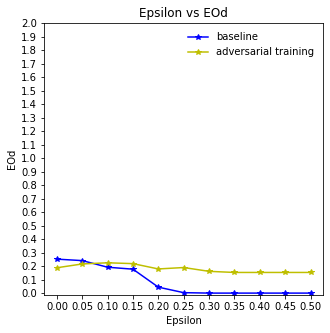

In [ ]:
# Plot the results for EOd vs Epsilon for both the baseline and adversarially trained models.

plt.figure(figsize=(5,5))
plt.plot(epsilons, EOd, label='baseline', color='b', marker='*')
plt.plot(epsilons, EOd_adv, label='adversarial training', color='y', marker='*')
plt.yticks(np.arange(0, 2.1, step=0.1))
plt.xticks(np.arange(0, .55, step=0.05))
plt.title("Epsilon vs EOd")
plt.xlabel("Epsilon")
plt.ylabel("EOd")
plt.legend(frameon=False, loc = 'best')
plt.show()

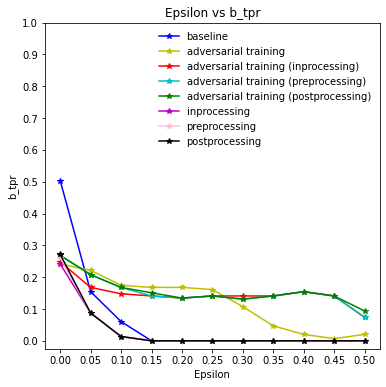

In [ ]:
# Plot the results for b_tpr vs Epsilon for both the baseline and adversarially trained models.
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.plot(epsilons, b_tpr, label='baseline', color='b', marker='*')
plt.plot(epsilons, b_tpr_adv, label='adversarial training', color='y', marker='*')

# UNCOMMENT THE BELOW LINES TO ADD THE RESULTS FOR THE OTHER ADVERSARIAL TRAINING METHODS (PREPROCESSING AND POSTPROCESSING) AND THE OTHER BASELINE METHODS (PREPROCESSING AND POSTPROCESSING)
# plt.plot(epsilons, b_tpr_advf, label='adversarial training (inprocessing)', color='r', marker='*')
# plt.plot(epsilons, b_tpr_advf_pre, label='adversarial training (preprocessing)', color='c', marker='*')
# plt.plot(epsilons, b_tpr_advf_post, label='adversarial training (postprocessing)', color='g', marker='*')
# plt.plot(epsilons, b_tpr_f, label='inprocessing', color='m', marker='*')
# plt.plot(epsilons, b_tpr_f_pre, label='preprocessing', color='pink', marker='*')
# plt.plot(epsilons, b_tpr_f_post, label='postprocessing', color='k', marker='*')

plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .55, step=0.05))
plt.title("Epsilon vs b_tpr")
plt.xlabel("Epsilon")
plt.ylabel("b_tpr")
plt.legend(frameon=False, loc = 'best')
plt.show()

In [ ]:
# CELL 9: MULTI-ATTRIBUTE FAIRNESS EVALUATION
# This cell prepares additional demographic attributes for comprehensive fairness testing.
# Tests fairness not just on race, but also on gender, age, and education.
# This validates that the fairness method generalizes across multiple dimensions.

# Extract demographic attributes for the test set from the original, cleaned data.
# We use the indices from the x_test dataframe (which comes from the preprocessed data,
# already filtered for White and Black races) to ensure consistency.

# The 'data' DataFrame from CELL 1 already contains the original (non-one-hot-encoded)
# features after initial cleaning and removal of missing values.
# We will use this 'data' DataFrame and filter it using the indices of 'x_test'.
x_test_full = data.loc[x_test.index]

# Extract different sensitive attributes
def extract_attribute_binary(data, attribute_name):
    """
    Extract a binary sensitive attribute from data.
    Returns a binary array (0 or 1) for comparison.
    """
    if attribute_name == 'gender':
        # The 'sex' column in the original data maps to 'gender' here.
        # 1 = Female, 0 = Male
        return np.where(data['gender'].str.strip() == 'Female', 1, 0)
    elif attribute_name == 'age_group':
        # 1 = Age >= 40, 0 = Age < 40
        return np.where(data['age'] >= 40, 1, 0)
    elif attribute_name == 'education':
        # 1 = Advanced education (Bachelors, Masters, Prof-school, Doctorate)
        # 0 = No advanced education
        advanced = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']
        return np.where(data['education'].isin(advanced), 1, 0)
    elif attribute_name == 'marital':
        # 1 = Married, 0 = Not married
        return np.where(data['marital-status'].str.contains('Married'), 1, 0)

# Store attributes for evaluation
test_attributes = {
    # 'x_test' itself is one-hot encoded, so we use 'x_test_full' for original 'race'
    'race': np.where(x_test_full['race'].str.strip() == 'Black', 1, 0),
    'gender': extract_attribute_binary(x_test_full, 'gender'),
    'age_group': extract_attribute_binary(x_test_full, 'age_group'),
    'education': extract_attribute_binary(x_test_full, 'education'),
    'marital': extract_attribute_binary(x_test_full, 'marital')
}

attribute_labels = {
    'race': ('Black', 'White'),
    'gender': ('Female', 'Male'),
    'age_group': ('Age ≥ 40', 'Age < 40'),
    'education': ('Advanced Ed.', 'No Advanced Ed.'),
    'marital': ('Married', 'Single/Other')
}

print("Demographic attributes extracted for multi-attribute fairness evaluation:")
for attr, (g0, g1) in attribute_labels.items():
    count0 = np.sum(test_attributes[attr] == 1)
    count1 = np.sum(test_attributes[attr] == 0)
    print(f"  {attr}: {g0} ({count0}), {g1} ({count1})")

In [ ]:
# CELL 10: MULTI-ATTRIBUTE FAIRNESS TESTING ACROSS ALL ATTRIBUTES
# Tests fairness metrics on multiple demographic attributes simultaneously.
# Shows that the fairness method doesn't just work on race, but generalizes to other dimensions.

def test_multi_attribute(model, test_loader, test_attributes, attribute_labels, epsilon=0.1):
    """
    Comprehensive fairness evaluation across multiple demographic attributes.

    Parameters:
        model: Trained classifier
        test_loader: Test data loader
        test_attributes: Dictionary of {attribute_name: binary_values}
        attribute_labels: Dictionary of {attribute_name: (group0_label, group1_label)}
        epsilon: Perturbation budget for adversarial attack

    Returns:
        Dictionary with fairness metrics for each attribute
    """

    model.eval()
    results = {}

    for data, target, sen in test_loader:
        target = target.long()
        data.requires_grad = True

        # Original predictions
        output_orig = model(data)

        # Adversarial predictions
        data_adv = pgd_attack(model, data, target, epsilon)
        output_adv = model(data_adv)

        # Evaluate on each attribute
        for attr_name, sen_values in test_attributes.items():
            idx_group0 = np.where(sen_values == 1)  # Group 0 (e.g., Black, Female, etc.)
            idx_group1 = np.where(sen_values == 0)  # Group 1 (e.g., White, Male, etc.)

            # Get predictions for each group
            pred_orig_g0 = output_orig[idx_group0].data.max(1, keepdim=True)[1]
            pred_orig_g1 = output_orig[idx_group1].data.max(1, keepdim=True)[1]
            pred_adv_g0 = output_adv[idx_group0].data.max(1, keepdim=True)[1]
            pred_adv_g1 = output_adv[idx_group1].data.max(1, keepdim=True)[1]

            target_g0 = target[idx_group0]
            target_g1 = target[idx_group1]

            # Compute metrics for each group
            try:
                metrics_g0_orig = model_eval(target_g0, pred_orig_g0.squeeze().cpu().numpy())
                metrics_g1_orig = model_eval(target_g1, pred_orig_g1.squeeze().cpu().numpy())
                metrics_g0_adv = model_eval(target_g0, pred_adv_g0.squeeze().cpu().numpy())
                metrics_g1_adv = model_eval(target_g1, pred_adv_g1.squeeze().cpu().numpy())

                # Compute fairness metrics
                di_orig = abs(metrics_g0_orig['DP'] - metrics_g1_orig['DP'])
                di_adv = abs(metrics_g0_adv['DP'] - metrics_g1_adv['DP'])

                eod_orig = abs(metrics_g0_orig['TPR'] - metrics_g1_orig['TPR']) + \
                           abs(metrics_g0_orig['FPR'] - metrics_g1_orig['FPR'])
                eod_adv = abs(metrics_g0_adv['TPR'] - metrics_g1_adv['TPR']) + \
                          abs(metrics_g0_adv['FPR'] - metrics_g1_adv['FPR'])

                results[attr_name] = {
                    'DI_original': di_orig,
                    'DI_adversarial': di_adv,
                    'EOD_original': eod_orig,
                    'EOD_adversarial': eod_adv,
                    'group0_label': attribute_labels[attr_name][0],
                    'group1_label': attribute_labels[attr_name][1]
                }
            except Exception as e: # Catch specific exception and print it
                print(f"Error calculating metrics for attribute {attr_name}: {e}")
                results[attr_name] = {
                    'DI_original': np.nan,
                    'DI_adversarial': np.nan,
                    'EOD_original': np.nan,
                    'EOD_adversarial': np.nan,
                    'group0_label': attribute_labels[attr_name][0],
                    'group1_label': attribute_labels[attr_name][1]
                }

    return results

# Run multi-attribute evaluation on clean data and adversarial data
print("\n" + "="*80)
print("MULTI-ATTRIBUTE FAIRNESS EVALUATION")
print("="*80)
print(f"\nTesting on epsilon = 0.1 (baseline adversarial robustness)\n")

multi_attr_results = test_multi_attribute(classifier, test_loader, test_attributes, attribute_labels, epsilon=0.1)

# Display results in a readable format
print(f"{'Attribute':<15} {'Group 0':<20} {'DI (Original)':<15} {'DI (Adversarial)':<15} {'Difference':<15}")
print("-"*80)

for attr_name, metrics in multi_attr_results.items():
    if not np.isnan(metrics['DI_original']):
        di_orig = metrics['DI_original'] * 100
        di_adv = metrics['DI_adversarial'] * 100
        diff = di_adv - di_orig
        print(f"{attr_name:<15} {metrics['group0_label']:<20} {di_orig:>14.2f}% {di_adv:>14.2f}% {diff:>+14.2f}%")
    else:
        print(f"{attr_name:<15} {'(N/A)':<20} {'--':<15} {'--':<15} {'--':<15}")

print("\n" + "="*80)
print("KEY INSIGHT:")
print("="*80)
print("If DI (Adversarial) \u2248 DI (Original), the model maintains fairness under attack.")
print("If fairness degradation is small across ALL attributes, the method is robust!")
print("="*80)
